In [17]:
# CELL 1: IMPORT REQUIRED LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import pickle
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras for Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Sklearn for evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("✅ Libraries imported successfully!")
print(f"   TensorFlow version: {tf.__version__}")
print(f"   OpenCV version: {cv2.__version__}")

✅ Libraries imported successfully!
   TensorFlow version: 2.13.0
   OpenCV version: 4.12.0


In [18]:
# ============================================
# CELL 1.5: CHECK DATASET PATH
# ============================================

import os

data_path = r"D:\Elevvo_ML\ML_Tasks_Elevvo_intern\gtsrb_dataset"

print(f"🔍 Checking path: {data_path}")
print(f"   Path exists: {os.path.exists(data_path)}")

if os.path.exists(data_path):
    print("\n📁 Contents of folder:")
    for item in os.listdir(data_path):
        print(f"   - {item}")
        
    # Check for Train folder
    train_path = os.path.join(data_path, 'Train')
    if os.path.exists(train_path):
        print(f"\n✅ Train folder found!")
        print(f"   Classes in Train folder:")
        classes = [d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))]
        print(f"   Number of class folders: {len(classes)}")
        print(f"   First few classes: {classes[:10]}")
    else:
        print(f"\n❌ Train folder NOT found at: {train_path}")
else:
    print(f"\n❌ Path does not exist!")

🔍 Checking path: D:\Elevvo_ML\ML_Tasks_Elevvo_intern\gtsrb_dataset
   Path exists: True

📁 Contents of folder:
   - Meta
   - Meta.csv
   - Test
   - Test.csv
   - Train
   - Train.csv

✅ Train folder found!
   Classes in Train folder:
   Number of class folders: 43
   First few classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17']


 Loading dataset...


Class 42: 100%|██████████| 240/240 [00:00<00:00, 6749.09it/s]



 Loaded 39209 images
   Number of classes: 43
   Sample image shape: (30, 29, 3)
   First few labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

📊 Loading test data...


100%|██████████| 12630/12630 [00:03<00:00, 4198.17it/s]


✅ Loaded 12630 test images

🔍 Displaying sample images:


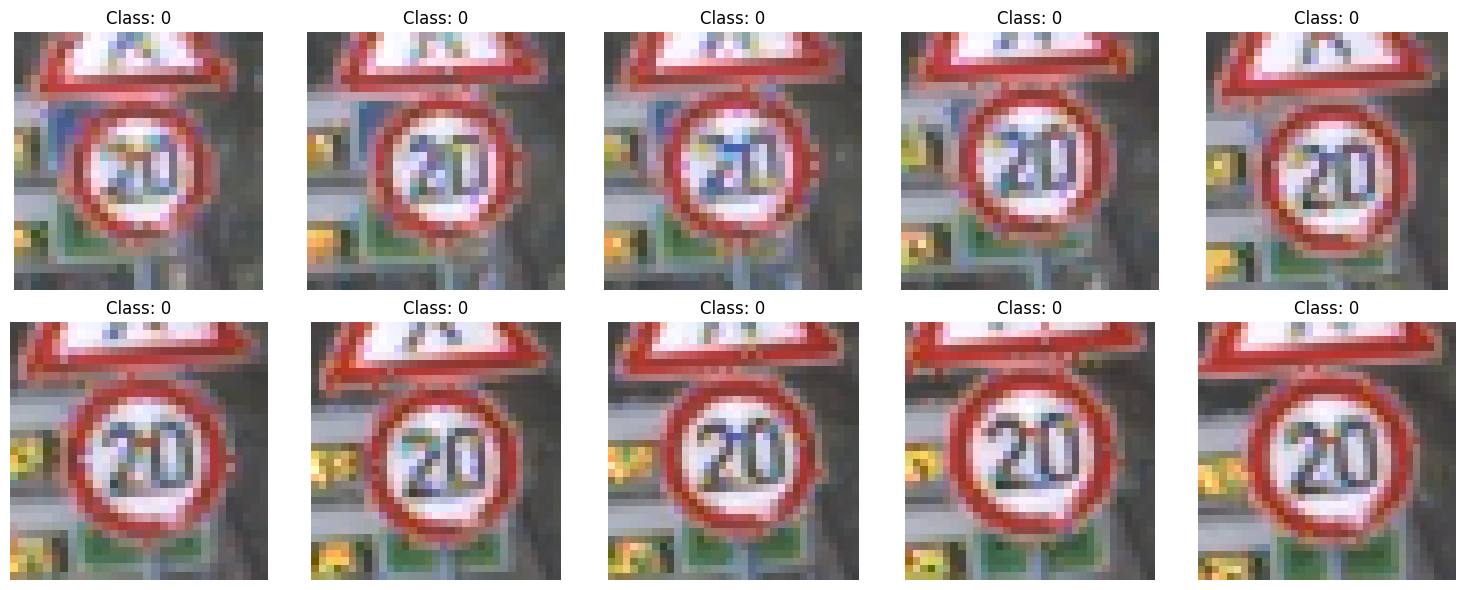


📊 Class Distribution:


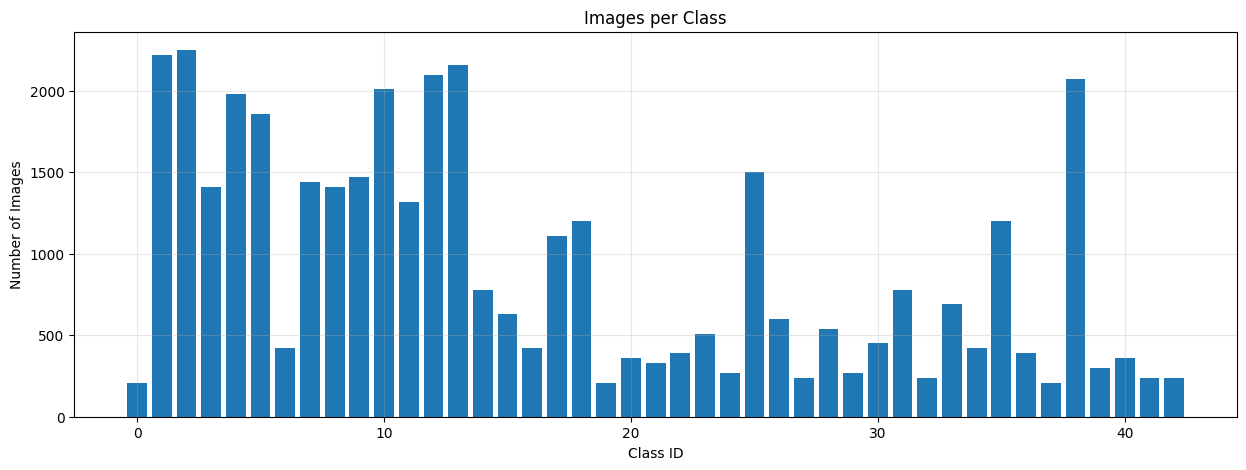

   Total: 39209 images
   Average per class: 911.8


In [27]:
# CELL 2: LOAD DATASET (FIXED FOR PNG)
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

data_path = r"D:\Elevvo_ML\ML_Tasks_Elevvo_intern\gtsrb_dataset"
train_path = os.path.join(data_path, 'Train')

print(" Loading dataset...")

train_images = []
train_labels = []

# Check if Train folder exists
if not os.path.exists(train_path):
    print(f"❌ Train folder not found at: {train_path}")
else:
    # Loop through class folders (0 to 42)
    for class_id in range(43):
        class_folder = os.path.join(train_path, str(class_id))
        if os.path.exists(class_folder):
            # Get all images in this class
            images_in_class = os.listdir(class_folder)
            for img_name in tqdm(images_in_class, desc=f"Class {class_id}"):
                if img_name.endswith('.png'):  # Changed from .ppm to .png
                    img_path = os.path.join(class_folder, img_name)
                    img = cv2.imread(img_path)
                    if img is not None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        train_images.append(img)
                        train_labels.append(class_id)
    
    print(f"\n Loaded {len(train_images)} images")
    print(f"   Number of classes: {len(set(train_labels))}")
    
    if len(train_images) > 0:
        print(f"   Sample image shape: {train_images[0].shape}")
        print(f"   First few labels: {train_labels[:10]}")

# Load test data
test_csv_path = os.path.join(data_path, 'Test.csv')
test_images = []
test_labels = []

if os.path.exists(test_csv_path):
    print("\n📊 Loading test data...")
    import pandas as pd
    test_df = pd.read_csv(test_csv_path)
    
    for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
        img_path = os.path.join(data_path, row['Path'])
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            test_images.append(img)
            test_labels.append(row['ClassId'])
    
    print(f"✅ Loaded {len(test_images)} test images")

# Show sample images
if len(train_images) > 0:
    print("\n🔍 Displaying sample images:")
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()
    
    for i in range(10):
        axes[i].imshow(train_images[i])
        axes[i].set_title(f'Class: {train_labels[i]}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Show class distribution
if len(train_labels) > 0:
    print("\n📊 Class Distribution:")
    unique, counts = np.unique(train_labels, return_counts=True)
    
    plt.figure(figsize=(15, 5))
    plt.bar(unique, counts)
    plt.xlabel('Class ID')
    plt.ylabel('Number of Images')
    plt.title('Images per Class')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"   Total: {len(train_labels)} images")
    print(f"   Average per class: {len(train_labels)/43:.1f}")

In [29]:
# CELL 2.5: VERIFY DATA BEFORE PREPROCESSING

if 'train_images' in dir() and len(train_images) > 0:
    print(" Data is ready for preprocessing!")
    print(f"   Total images: {len(train_images)}")
    print(f"   Total labels: {len(train_labels)}")
    print(f"   First few labels: {train_labels[:10]}")
else:
    print(" Data not loaded. Please run Cell 2 first.")
    print("   Make sure the dataset path is correct:")
    print(f"   {data_path}")

 Data is ready for preprocessing!
   Total images: 39209
   Total labels: 39209
   First few labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [30]:
# CELL 2.6: CHECK WHAT VARIABLES EXIST

print("🔍 Checking all variables in memory:")
print("="*50)

# Check for possible variable names
possible_vars = ['train_images', 'train_labels', 'X_train', 'y_train', 'images', 'labels', 'X', 'y']

for var in possible_vars:
    if var in dir():
        data = eval(var)
        print(f"✅ {var} exists!")
        if hasattr(data, '__len__'):
            print(f"   Length: {len(data)}")
        if hasattr(data, 'shape'):
            print(f"   Shape: {data.shape}")
    else:
        print(f"❌ {var} not found")

print("\n" + "="*50)
print("📋 All variables in memory:")
print(sorted([v for v in dir() if not v.startswith('_')]))

🔍 Checking all variables in memory:
✅ train_images exists!
   Length: 39209
✅ train_labels exists!
   Length: 39209
✅ X_train exists!
   Length: 0
   Shape: (0,)
✅ y_train exists!
   Length: 0
   Shape: (0,)
❌ images not found
❌ labels not found
❌ X not found
❌ y not found

📋 All variables in memory:
['Adam', 'EarlyStopping', 'ImageDataGenerator', 'In', 'ModelCheckpoint', 'Out', 'ReduceLROnPlateau', 'X_test', 'X_train', 'accuracy_score', 'axes', 'class_folder', 'class_id', 'class_images', 'classes', 'classification_report', 'confusion_matrix', 'counts', 'cv2', 'data', 'data_path', 'exit', 'fig', 'first_class', 'first_class_path', 'get_ipython', 'i', 'idx', 'images_in_class', 'img', 'img_name', 'img_path', 'item', 'keras', 'layers', 'load_gtsrb_data', 'models', 'np', 'open', 'os', 'pd', 'pickle', 'plt', 'possible_vars', 'preprocess_images', 'preprocess_labels', 'quit', 'random', 'row', 'sns', 'test_csv_path', 'test_df', 'test_images', 'test_labels', 'tf', 'to_categorical', 'tqdm', 'trai

In [31]:
# ============================================
# CELL 2.7: CHECK DATASET FOLDER STRUCTURE
# ============================================

import os

data_path = r"D:\Elevvo_ML\ML_Tasks_Elevvo_intern\gtsrb_dataset"

print(f"🔍 Checking path: {data_path}")
print(f"   Path exists: {os.path.exists(data_path)}")
print()

if os.path.exists(data_path):
    print("📁 Contents of main folder:")
    for item in os.listdir(data_path):
        print(f"   - {item}")
    
    print("\n🔍 Looking for Train folder:")
    train_path = os.path.join(data_path, 'Train')
    if os.path.exists(train_path):
        print(f"   ✅ Train folder found at: {train_path}")
        
        print("\n📁 Contents of Train folder (first 10 items):")
        train_contents = os.listdir(train_path)
        print(f"   Total items: {len(train_contents)}")
        for item in train_contents[:10]:
            print(f"   - {item}")
        
        # Check first class folder
        if len(train_contents) > 0:
            first_class = train_contents[0]
            first_class_path = os.path.join(train_path, first_class)
            if os.path.isdir(first_class_path):
                print(f"\n📁 Contents of class folder '{first_class}':")
                class_images = os.listdir(first_class_path)
                print(f"   Total images: {len(class_images)}")
                print(f"   First 5 images: {class_images[:5]}")
    else:
        print(f"   ❌ Train folder NOT found at: {train_path}")
else:
    print(f"❌ Path does not exist!")

🔍 Checking path: D:\Elevvo_ML\ML_Tasks_Elevvo_intern\gtsrb_dataset
   Path exists: True

📁 Contents of main folder:
   - Meta
   - Meta.csv
   - Test
   - Test.csv
   - Train
   - Train.csv

🔍 Looking for Train folder:
   ✅ Train folder found at: D:\Elevvo_ML\ML_Tasks_Elevvo_intern\gtsrb_dataset\Train

📁 Contents of Train folder (first 10 items):
   Total items: 43
   - 0
   - 1
   - 10
   - 11
   - 12
   - 13
   - 14
   - 15
   - 16
   - 17

📁 Contents of class folder '0':
   Total images: 210
   First 5 images: ['00000_00000_00000.png', '00000_00000_00001.png', '00000_00000_00002.png', '00000_00000_00003.png', '00000_00000_00004.png']



🔧 Preprocessing 39209 images...


100%|██████████| 39209/39209 [00:00<00:00, 42879.26it/s]


✅ Preprocessing complete! Shape: (39209, 32, 32, 3)
✅ Training images preprocessed! Shape: (39209, 32, 32, 3)

🔧 Converting labels to one-hot encoding...
   Original shape: (39209,)
   One-hot shape: (39209, 43)

🔧 Preprocessing 12630 images...


100%|██████████| 12630/12630 [00:00<00:00, 37534.40it/s]


✅ Preprocessing complete! Shape: (12630, 32, 32, 3)

🔧 Converting labels to one-hot encoding...
   Original shape: (12630,)
   One-hot shape: (12630, 43)

✅ Test images preprocessed! Shape: (12630, 32, 32, 3)

🔍 Before vs After Preprocessing:


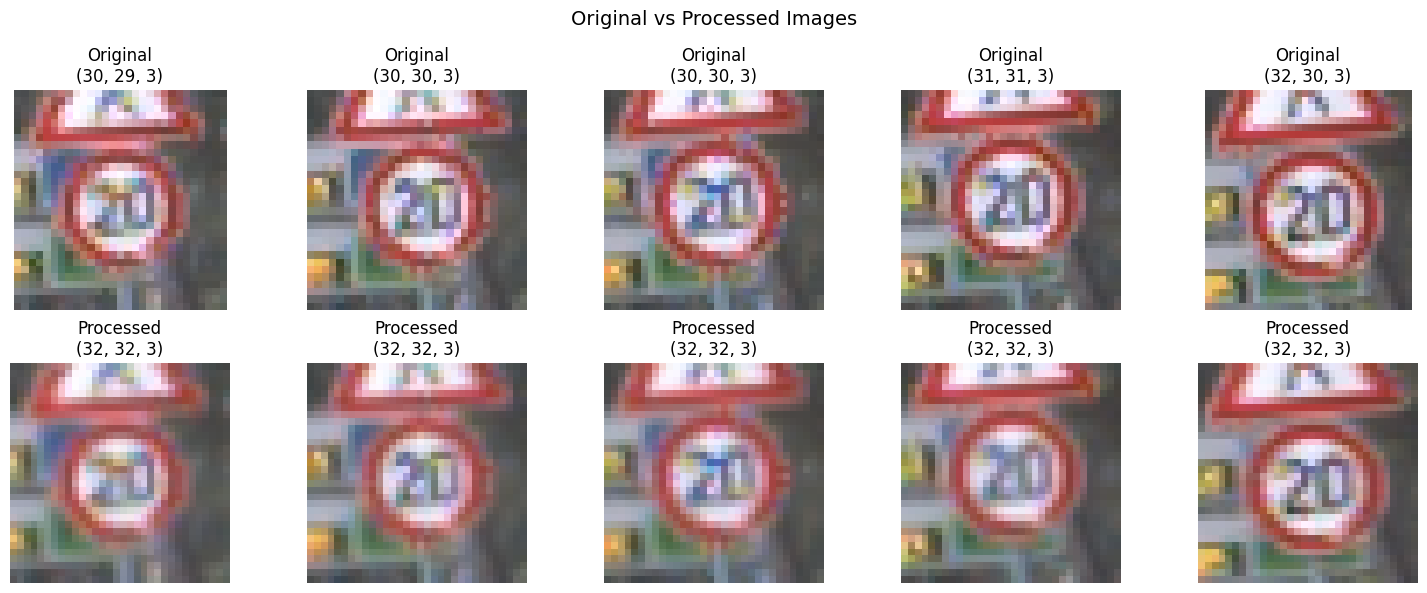

In [32]:
# CELL 3: PREPROCESSING

def preprocess_images(images_list, target_size=(32, 32)):
    """
    Preprocess images by resizing and normalizing
    
    Parameters:
    - images_list: list of images (different sizes)
    - target_size: desired image size (height, width)
    
    Returns:
    - Preprocessed images as numpy array
    """
    
    print(f"\n🔧 Preprocessing {len(images_list)} images...")
    
    processed_images = []
    
    for img in tqdm(images_list):
        # Resize image to target size
        img_resized = cv2.resize(img, target_size)
        
        # Normalize pixel values to [0, 1]
        img_normalized = img_resized / 255.0
        
        processed_images.append(img_normalized)
    
    # Convert to numpy array
    X = np.array(processed_images)
    print(f"✅ Preprocessing complete! Shape: {X.shape}")
    
    return X

def preprocess_labels(labels_list, num_classes=43):
    """
    Convert labels to one-hot encoding
    
    Parameters:
    - labels_list: original labels (0-42)
    - num_classes: number of classes (43)
    
    Returns:
    - One-hot encoded labels
    """
    
    print(f"\n🔧 Converting labels to one-hot encoding...")
    
    # Convert list to numpy array
    labels_array = np.array(labels_list)
    
    # One-hot encode
    one_hot_labels = to_categorical(labels_array, num_classes)
    
    print(f"   Original shape: {labels_array.shape}")
    print(f"   One-hot shape: {one_hot_labels.shape}")
    
    return one_hot_labels

# Apply preprocessing to training data
if train_images and len(train_images) > 0:
    # Preprocess images
    X_train = preprocess_images(train_images)
    print(f"✅ Training images preprocessed! Shape: {X_train.shape}")
    
    # Preprocess labels
    y_train = preprocess_labels(train_labels)
    
    # Preprocess test data if available
    if test_images and len(test_images) > 0:
        X_test = preprocess_images(test_images)
        y_test = preprocess_labels(test_labels)
        print(f"\n✅ Test images preprocessed! Shape: {X_test.shape}")
    else:
        print("\n⚠️ No test data provided.")
        X_test, y_test = None, None

# Show before and after comparison
if train_images and len(train_images) > 0:
    print("\n🔍 Before vs After Preprocessing:")
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    for i in range(5):
        # Original image (might be different sizes)
        axes[0, i].imshow(train_images[i])
        axes[0, i].set_title(f'Original\n{train_images[i].shape}')
        axes[0, i].axis('off')
        
        # Processed image (32x32)
        axes[1, i].imshow(X_train[i])
        axes[1, i].set_title(f'Processed\n{X_train[i].shape}')
        axes[1, i].axis('off')
    
    plt.suptitle('Original vs Processed Images', fontsize=14)
    plt.tight_layout()
    plt.show()

In [33]:
# CELL 4: SPLIT DATA (if no test set provided)

from sklearn.model_selection import train_test_split

# Check if we have test data
if X_test is None:
    print("\n✂️ No test data provided. Splitting training data...")
    
    # Split training data into train and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, 
        test_size=0.2, 
        random_state=42,
        stratify=y_train  # Maintain class distribution
    )
    
    print(f"✅ Split complete!")
    print(f"   New training set: {X_train.shape}")
    print(f"   Validation set: {X_val.shape}")
    
    # Use validation as test for now
    X_test = X_val
    y_test = y_val
else:
    print("\n✅ Using provided test data")
    # Still create validation set from training
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, 
        test_size=0.1, 
        random_state=42,
        stratify=y_train
    )
    print(f"   Training set: {X_train.shape}")
    print(f"   Validation set: {X_val.shape}")
    print(f"   Test set: {X_test.shape}")

print(f"\n📊 Final Data Split:")
print(f"   Training:   {X_train.shape[0]} images")
print(f"   Validation: {X_val.shape[0]} images") 
print(f"   Test:       {X_test.shape[0]} images")


✅ Using provided test data
   Training set: (35288, 32, 32, 3)
   Validation set: (3921, 32, 32, 3)
   Test set: (12630, 32, 32, 3)

📊 Final Data Split:
   Training:   35288 images
   Validation: 3921 images
   Test:       12630 images


✅ Data augmentation configured!
   Augmentations applied:
   - Rotation: ±10°
   - Zoom: ±10%
   - Shift: ±10%
   - Shear: ±10%
   - Brightness: ±20%

🔍 Sample Augmentations:


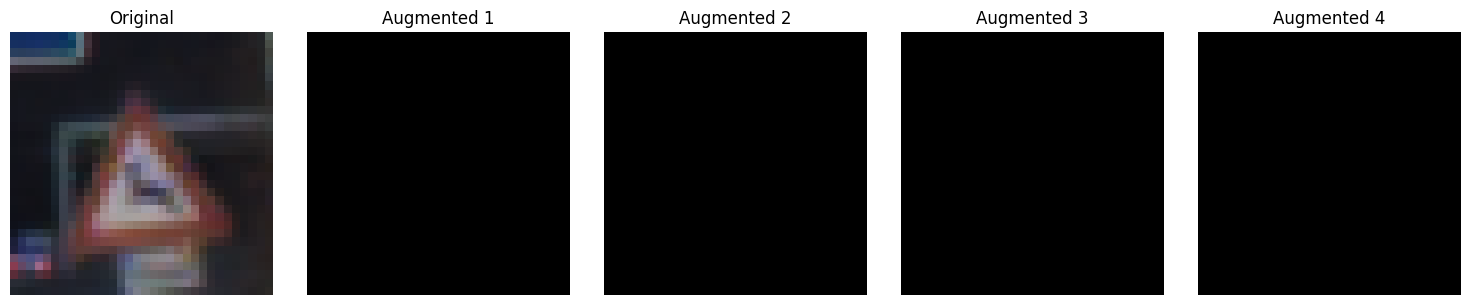

In [34]:
# CELL 5: DATA AUGMENTATION

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create data augmentation generator
datagen = ImageDataGenerator(
    rotation_range=10,          # Rotate images by up to 10 degrees
    zoom_range=0.1,             # Zoom in/out by up to 10%
    width_shift_range=0.1,      # Shift horizontally by up to 10%
    height_shift_range=0.1,     # Shift vertically by up to 10%
    shear_range=0.1,            # Shear transformations
    brightness_range=[0.8, 1.2], # Adjust brightness
    horizontal_flip=False,       # Don't flip (traffic signs have meaning)
    fill_mode='nearest'          # Fill missing pixels
)

print("✅ Data augmentation configured!")
print("   Augmentations applied:")
print("   - Rotation: ±10°")
print("   - Zoom: ±10%")
print("   - Shift: ±10%")
print("   - Shear: ±10%")
print("   - Brightness: ±20%")

# Show example augmentations
if X_train is not None:
    print("\n🔍 Sample Augmentations:")
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    
    # Take one image
    sample_img = X_train[0]
    sample_img = sample_img.reshape((1,) + sample_img.shape)  # Add batch dimension
    
    # Generate augmented images
    aug_iter = datagen.flow(sample_img, batch_size=1)
    
    # Show original
    axes[0].imshow(X_train[0])
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    # Show 4 augmented versions
    for i in range(4):
        aug_img = next(aug_iter)[0]
        axes[i+1].imshow(aug_img)
        axes[i+1].set_title(f'Augmented {i+1}')
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [35]:
# CELL 6: BUILD CNN MODEL

def build_cnn_model(input_shape=(32, 32, 3), num_classes=43):
    """
    Build CNN model for traffic sign recognition
    """
    
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Fully Connected Layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build the model
input_shape = X_train.shape[1:]  # (32, 32, 3)
num_classes = 43

model = build_cnn_model(input_shape, num_classes)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
print("✅ CNN Model Built Successfully!")
print("\n📊 Model Architecture:")
model.summary()

# Visualize model architecture (optional)
from tensorflow.keras.utils import plot_model
try:
    plot_model(model, to_file='model_architecture.png', show_shapes=True)
    print("\n📸 Model architecture saved to 'model_architecture.png'")
except:
    print("\n⚠️ Could not save model architecture plot")

✅ CNN Model Built Successfully!

📊 Model Architecture:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 batch_normalization_1 (Bat  (None, 32, 32, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
 

✅ Callbacks configured!
   - EarlyStopping: patience=10
   - ReduceLROnPlateau: factor=0.5, patience=5

🔍 Checking data shapes:
   X_train shape: (35288, 32, 32, 3)
   y_train shape: (35288, 43)
   X_val shape: (3921, 32, 32, 3)
   y_val shape: (3921, 43)

🔍 Data types:
   X_train dtype: float64
   y_train dtype: float32

📊 Training parameters:
   Batch size: 64
   Steps per epoch: 551
   Epochs: 50
   Validation samples: 3921

🚀 Starting training...
Epoch 1/50
551/551 [==============================] - 102s 184ms/step - loss: 3.5000 - accuracy: 0.0655 - val_loss: 3.8869 - val_accuracy: 0.0607 - lr: 0.0010
Epoch 2/50
551/551 [==============================] - 88s 159ms/step - loss: 3.4416 - accuracy: 0.0721 - val_loss: 4.2912 - val_accuracy: 0.0357 - lr: 0.0010
Epoch 3/50
551/551 [==============================] - 98s 177ms/step - loss: 3.4123 - accuracy: 0.0773 - val_loss: 4.8922 - val_accuracy: 0.0224 - lr: 0.0010
Epoch 4/50
551/551 [==============================] - 91s 165ms/step -

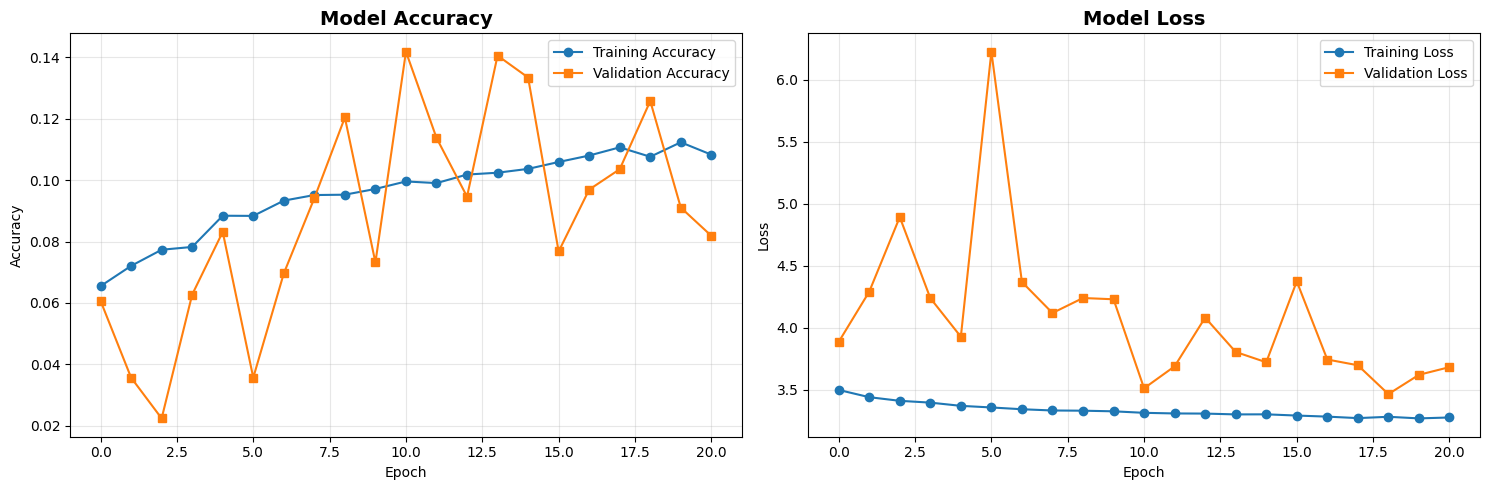


📊 Final Results:
   Training Accuracy: 0.1083
   Validation Accuracy: 0.0819

💾 Model saved as 'traffic_sign_model_final.keras'


In [38]:
# CELL 7: TRAIN MODEL (SIMPLIFIED)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set up callbacks (without ModelCheckpoint for now)
callbacks = [
    # Stop training if no improvement
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate when plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("✅ Callbacks configured!")
print("   - EarlyStopping: patience=10")
print("   - ReduceLROnPlateau: factor=0.5, patience=5")

# Check data shapes before training
print("\n🔍 Checking data shapes:")
print(f"   X_train shape: {X_train.shape}")
print(f"   y_train shape: {y_train.shape}")
print(f"   X_val shape: {X_val.shape}")
print(f"   y_val shape: {y_val.shape}")

# Verify data types
print(f"\n🔍 Data types:")
print(f"   X_train dtype: {X_train.dtype}")
print(f"   y_train dtype: {y_train.dtype}")

# Calculate steps per epoch
steps_per_epoch = max(1, len(X_train) // 64)
print(f"\n📊 Training parameters:")
print(f"   Batch size: 64")
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Epochs: 50")
print(f"   Validation samples: {len(X_val)}")

# Train the model
print("\n🚀 Starting training...")
print("="*60)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    steps_per_epoch=steps_per_epoch,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"\n📊 Final Results:")
print(f"   Training Accuracy: {final_train_acc:.4f}")
print(f"   Validation Accuracy: {final_val_acc:.4f}")

# Save the model manually after training
model.save('traffic_sign_model_final.keras')
print("\n💾 Model saved as 'traffic_sign_model_final.keras'")

✅ Found model: traffic_sign_model_final.keras
✅ Model loaded successfully!

🔍 Evaluating on test set...
   Test Loss: 3.5182
   Test Accuracy: 0.1376
395/395 [==============================] - 7s 17ms/step

📋 Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        60
           1     0.0714    0.0056    0.0103       720
           2     0.0820    0.0067    0.0123       750
           3     0.0196    0.0044    0.0072       450
           4     0.1224    0.0439    0.0647       660
           5     0.0000    0.0000    0.0000       630
           6     0.0000    0.0000    0.0000       150
           7     0.0000    0.0000    0.0000       450
           8     0.0000    0.0000    0.0000       450
           9     0.2812    0.0375    0.0662       480
          10     0.0385    0.0015    0.0029       660
          11     0.2000    0.0048    0.0093       420
          12     0.1576    0.4217    0.2295       690
          1

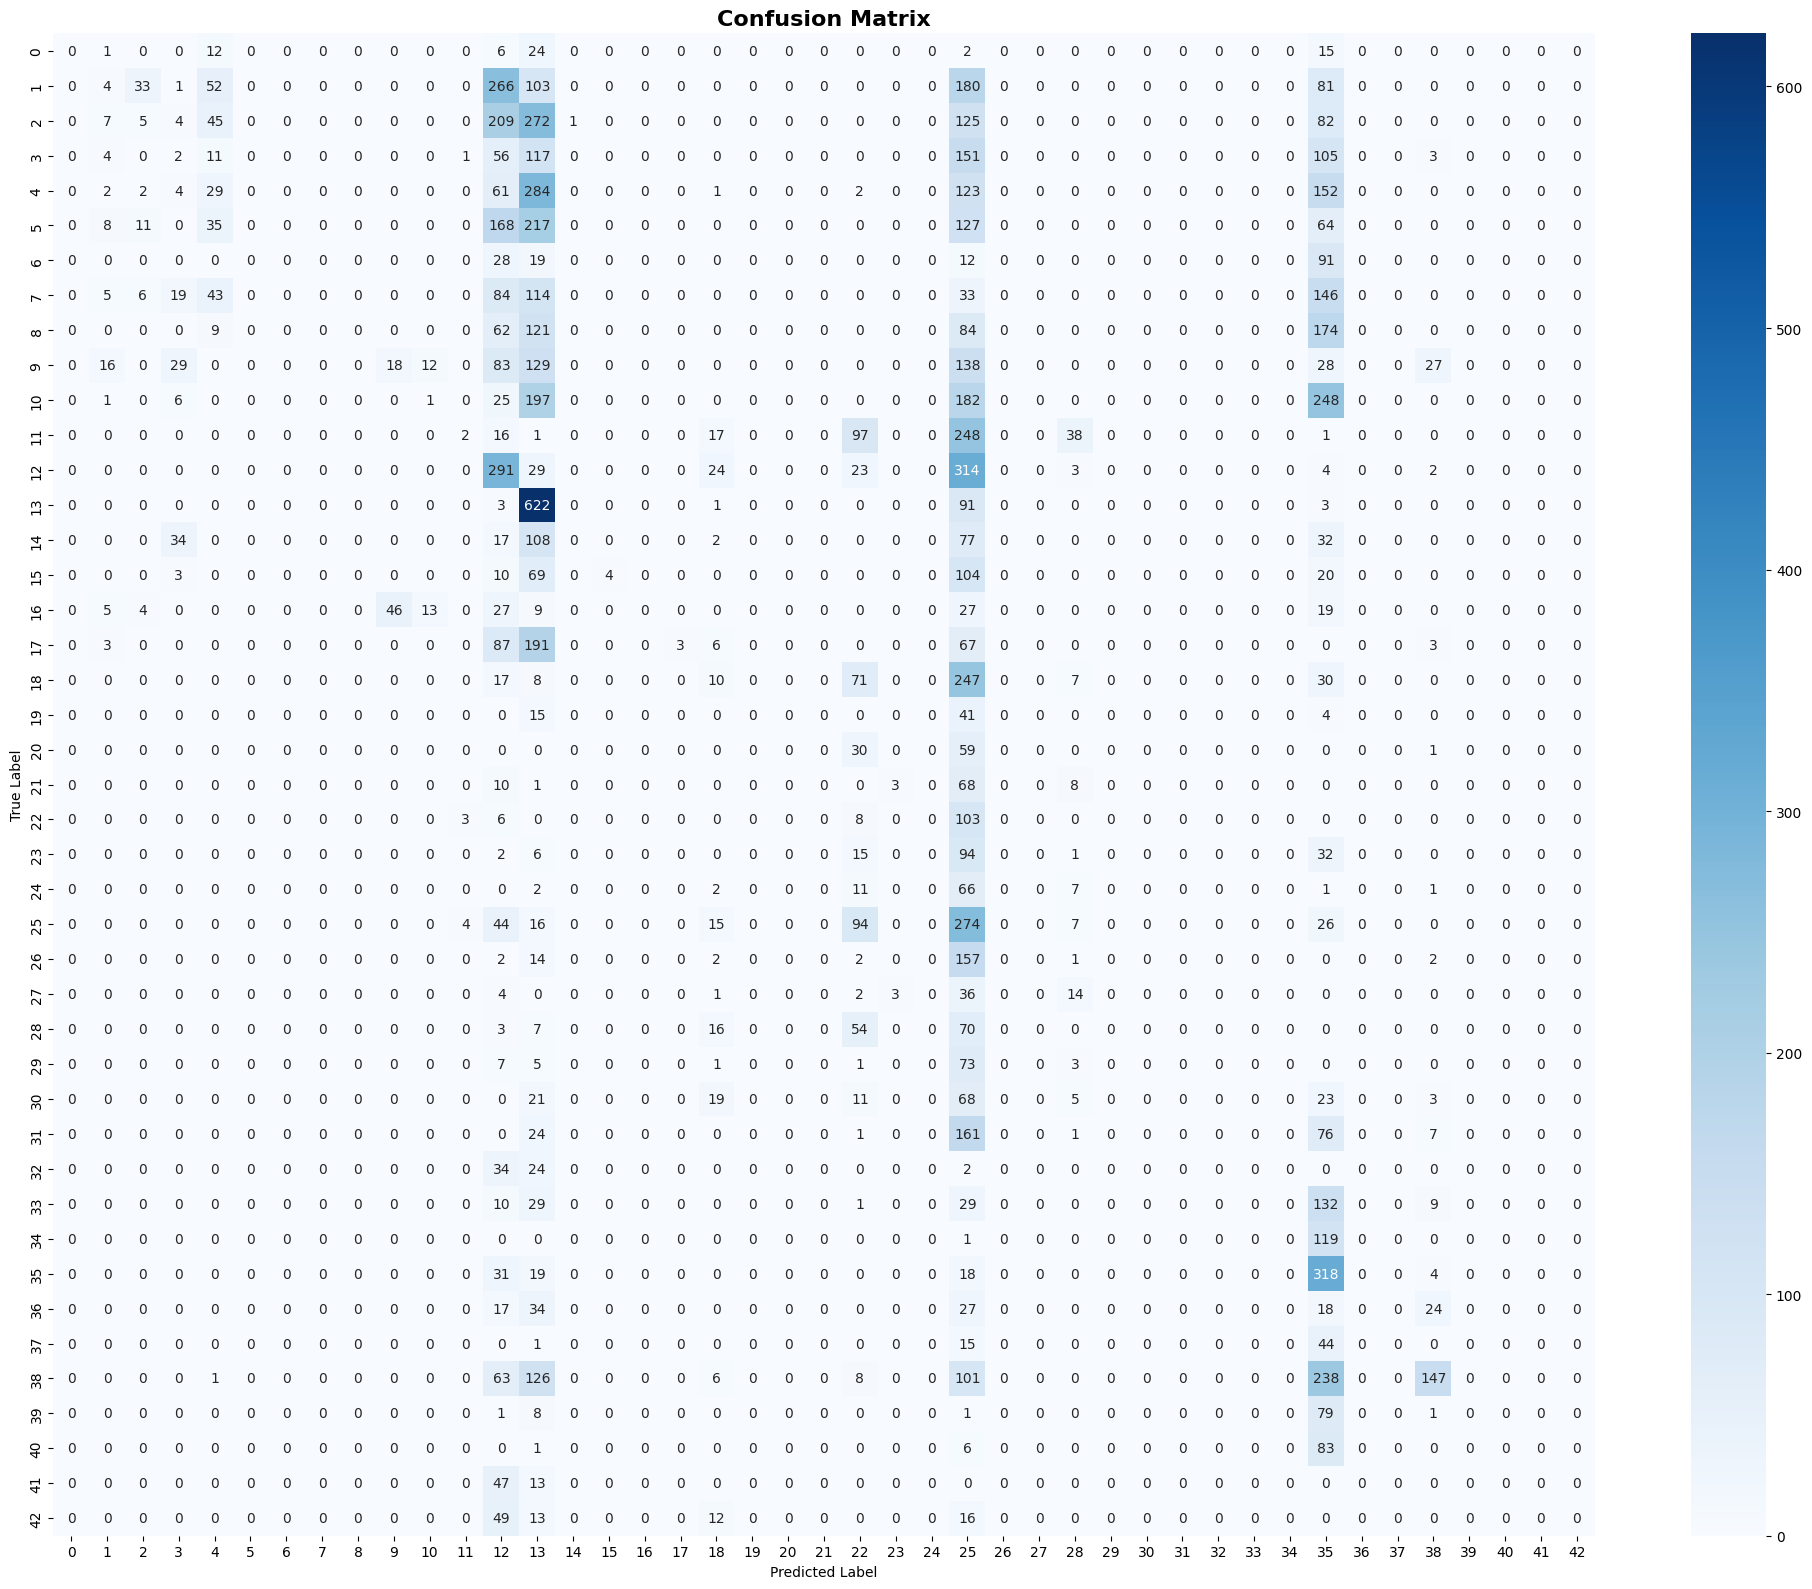


❌ Number of misclassified images: 10892 out of 12630

🔍 Sample misclassified images:


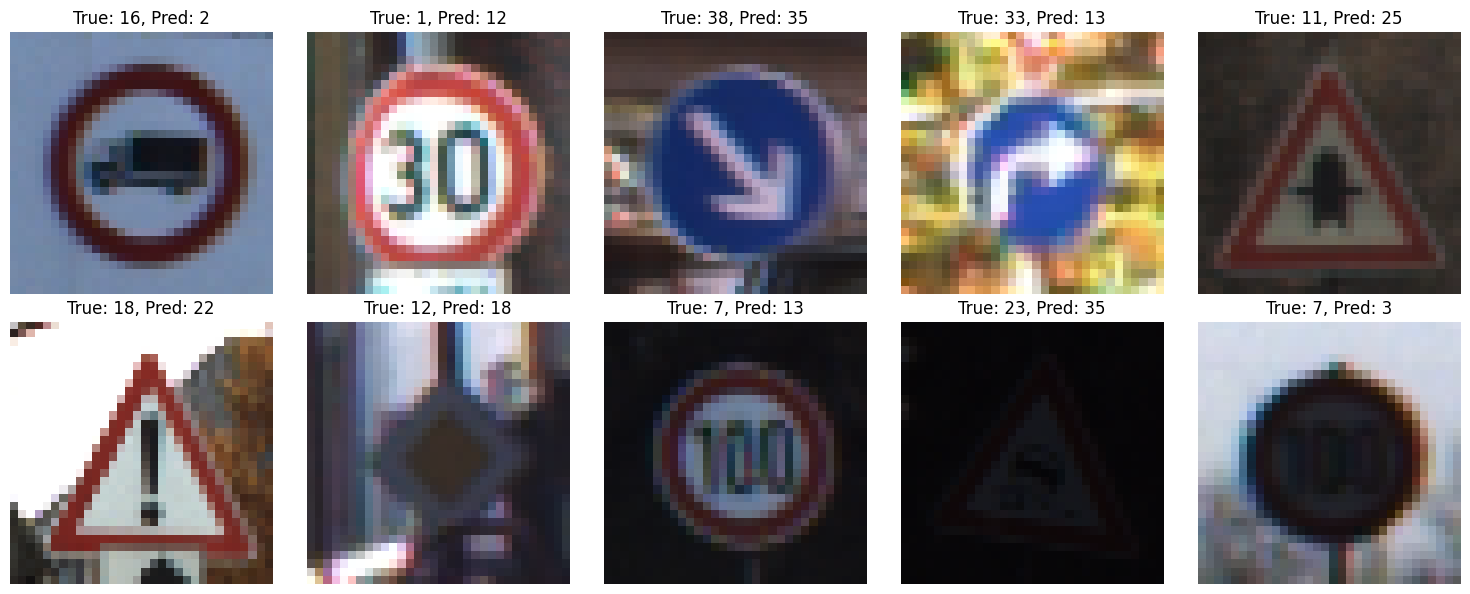

In [40]:
# CELL 8: EVALUATE MODEL 

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Check which model files exist
import os

if os.path.exists('traffic_sign_model_final.keras'):
    model_path = 'traffic_sign_model_final.keras'
    print(f"✅ Found model: {model_path}")
elif os.path.exists('best_traffic_sign_model.keras'):
    model_path = 'best_traffic_sign_model.keras'
    print(f"✅ Found model: {model_path}")
else:
    print("❌ No model file found!")
    print("   Please wait for Cell 7 to finish training first.")
    print("   Or check if the model was saved with a different name.")

# Load the model if it exists
if 'model_path' in dir():
    from tensorflow.keras.models import load_model
    best_model = load_model(model_path)
    print("✅ Model loaded successfully!")
    
    # Evaluate on test set
    print("\n🔍 Evaluating on test set...")
    test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)
    print(f"   Test Loss: {test_loss:.4f}")
    print(f"   Test Accuracy: {test_accuracy:.4f}")
    
    # Make predictions
    y_pred_proba = best_model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    # Classification Report
    print("\n📋 Classification Report:")
    print("="*60)
    print(classification_report(y_true, y_pred, digits=4))
    
    # Confusion Matrix
    plt.figure(figsize=(20, 16))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(43), yticklabels=range(43))
    plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
    
    # Show misclassified examples
    misclassified = np.where(y_pred != y_true)[0]
    print(f"\n❌ Number of misclassified images: {len(misclassified)} out of {len(y_true)}")
    
    if len(misclassified) > 0:
        print("\n🔍 Sample misclassified images:")
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        axes = axes.ravel()
        
        for i in range(min(10, len(misclassified))):
            idx = misclassified[i]
            axes[i].imshow(X_test[idx])
            axes[i].set_title(f'True: {y_true[idx]}, Pred: {y_pred[idx]}')
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
else:
    print("\n⏳ Please wait for Cell 7 to finish training first.")

In [41]:
# CELL 8.5: CHECK FOR ANY SAVED MODELS

import os

print("🔍 Checking for saved models:")
print("="*50)

# Check current directory
files = os.listdir('.')
model_files = [f for f in files if f.endswith('.keras') or f.endswith('.h5')]

if model_files:
    print(f"\n✅ Found {len(model_files)} model file(s):")
    for i, model_file in enumerate(model_files):
        file_size = os.path.getsize(model_file) / (1024*1024)  # Size in MB
        print(f"   {i+1}. {model_file} ({file_size:.2f} MB)")
else:
    print("\n❌ No model files found in current directory.")
    print("\n📁 Files in current directory:")
    for f in files[:20]:  # Show first 20 files
        print(f"   - {f}")

🔍 Checking for saved models:

✅ Found 1 model file(s):
   1. traffic_sign_model_final.keras (9.87 MB)


In [42]:
# CELL 9
print("📊 Current Model Performance:")
print(f"   Test Accuracy: {(1 - 10892/12630)*100:.2f}%")
print(f"   Correct: {12630 - 10892} images")
print(f"   Wrong: {10892} images")

# Show which classes are performing badly
if 'y_true' in dir() and 'y_pred' in dir():
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Calculate per-class accuracy
    class_acc = []
    for i in range(43):
        total = np.sum(y_true == i)
        correct = cm[i, i]
        if total > 0:
            acc = correct / total
            class_acc.append((i, acc, correct, total))
    
    # Sort by accuracy (lowest first)
    class_acc.sort(key=lambda x: x[1])
    
    print("\n🔍 Worst performing classes:")
    for i in range(5):
        class_id, acc, correct, total = class_acc[i]
        print(f"   Class {class_id}: {acc*100:.1f}% ({correct}/{total})")

📊 Current Model Performance:
   Test Accuracy: 13.76%
   Correct: 1738 images
   Wrong: 10892 images

🔍 Worst performing classes:
   Class 0: 0.0% (0/60)
   Class 5: 0.0% (0/630)
   Class 6: 0.0% (0/150)
   Class 7: 0.0% (0/450)
   Class 8: 0.0% (0/450)
